In [78]:
from pyslfp import (
    FingerPrint,
    IceModel,
    plot,
    averaging_operator,
)
from pyslfp_extras.ice_thickness import IceSheetChange
from pygeoinf_extras import standard_dev, expectation
from project import error_plot
import numpy as np

Packages:

- `pyslfp`: [Python Sea Level Fingerprints](https://github.com/da380/pyslfp)
- `pygeoinf`: [A Python Library for Geophysical Inference](https://github.com/da380/pygeoinf)

- `pyslfp_extras` and `pygeoinf_extras`: Extensions to the pyslfp and pygeoinf libraries
- `project`: Shared utility code for this project


# Sea Surface Height

Sea Level (SL), also known as Relative Sea Level, is the difference in elevation between the sea surface and the solid earth surface. A change in this elevation difference is termed Sea Level Change (SLC).

Sea Surface Height (SSH), also known as Absolute Sea Level, is defined as the elevation of the sea surface above a reference ellipsoid.

Satellite altimetry measures Sea Surface Height Change (SSHC). However, the quantity of primary interest is SLC, as this is what is directly relevant to coastal communities and policy-makers. 

The sea level fingerprint response to a surface load, $\zeta$, comprises the fields ($SLC, \mathbf{u}, \phi, \omega$).

SSHC is related to SLC by:
$$\text{SSHC} = \text{SLC} + u_r $$

Global Mean Sea Level is defined as the spatial average of the sea level.

## Implementation in pyslfp

This was implemented into the pyslfp library.

First a load is generated, in this case a load across all ice sheets, normalised to produce 1mm of GMSL change.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x14fc6d550>)

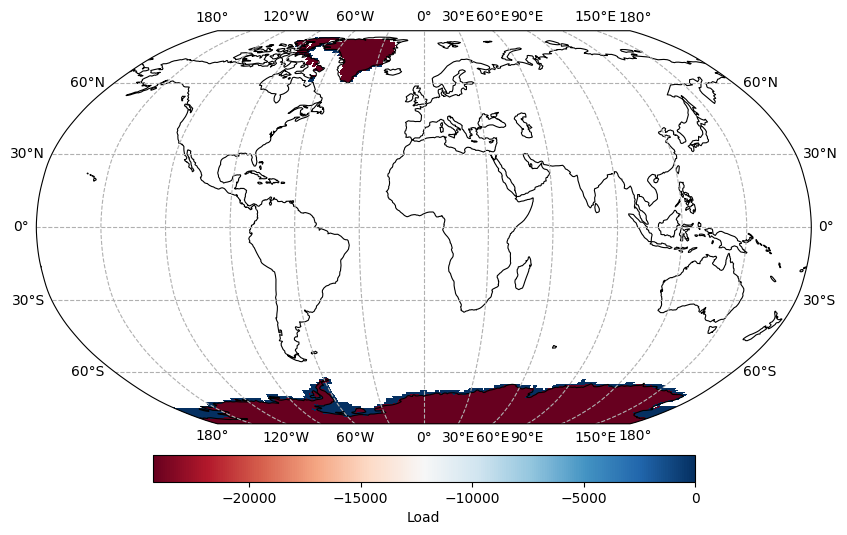

In [56]:
fp = FingerPrint(lmax=256)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)

load = fp.direct_load_from_ice_thickness_change(
    fp.ice_projection(value=0)
)
load /= fp.mean_sea_level_change(
    direct_load=load
)  # normalise to 1mm GMSL change

plot(load * fp.ice_projection(), colorbar_label="Load")

A finger print response can then be generated from this load and then passed to a function to calculate the sea surface height change:

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x15033f920>)

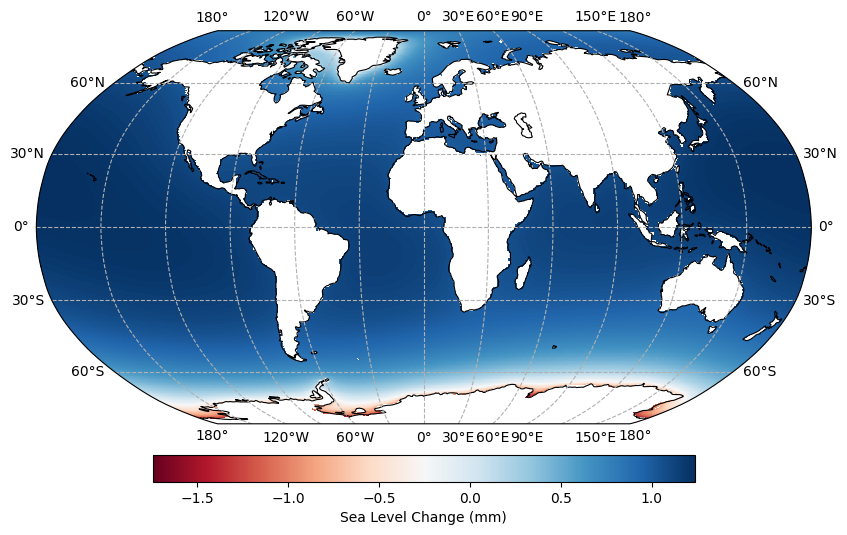

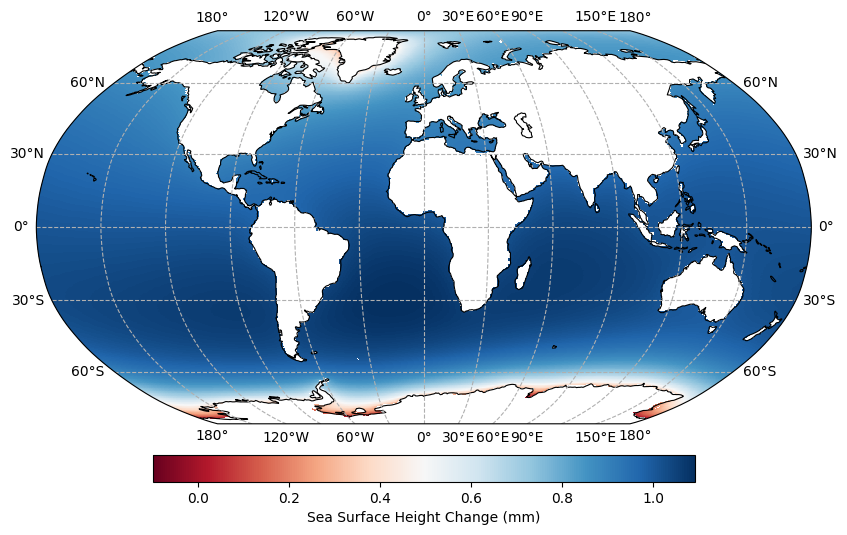

In [57]:
slc, dis, _, avc = fp(direct_load=load)

plot(
    slc * fp.ocean_projection(),
    colorbar_label="Sea Level Change (mm)",
)

sshc = fp.sea_surface_height_change(slc, dis, avc)

plot(
    sshc * fp.ocean_projection(),
    colorbar_label="Sea Surface Height Change (mm)",
)

When sampling altimetry data, however, typically the range of measurements is limited to within 66 degrees N/S, which can be implemented.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x1505cb8c0>)

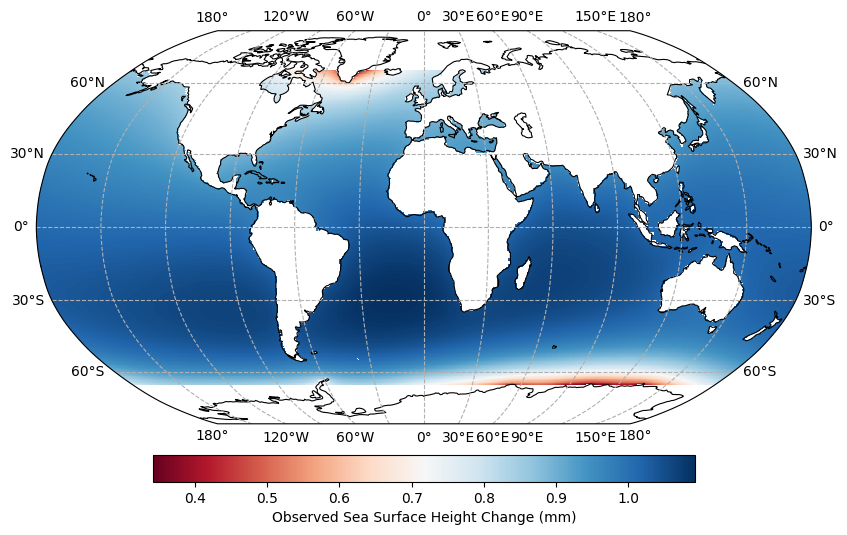

In [58]:
observed_sshc = sshc * fp.altimetry_projection(
    latitude_min=-66.0, latitude_max=66.0
)

plot(
    observed_sshc,
    colorbar_label="Observed Sea Surface Height Change (mm)",
)

Often GMSL estimates use SSHC surface averages to approximate averaging SLC, however errors are associated with this method. 

To simply show the error at this stage, we can take the surface average across the oceans for both and compare these values:

In [59]:
true_gmsl = fp.ocean_average(slc)
ssh_gmsl = fp.ocean_average(sshc)
estimated_gmsl = fp.integrate(
    sshc * fp.altimetry_projection(value=0)
) / fp.integrate(fp.altimetry_projection(value=0))

percentage_error = (
    100 * abs(true_gmsl - estimated_gmsl) / abs(true_gmsl)
)

print(f"True GMSL change (using SLC): {true_gmsl:.3f} mm")
print(f"GMSL change using SSHC: {ssh_gmsl:.3f} mm")
print(
    f"Estimated GMSL change from observations: {estimated_gmsl:.3f} mm"
)
print(f"Percentage error: {percentage_error:.2f}%")

True GMSL change (using SLC): 1.000 mm
GMSL change using SSHC: 0.967 mm
Estimated GMSL change from observations: 0.987 mm
Percentage error: 1.34%


## Gaussian Operators



In [60]:
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

To explore how 

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x1506e88f0>)

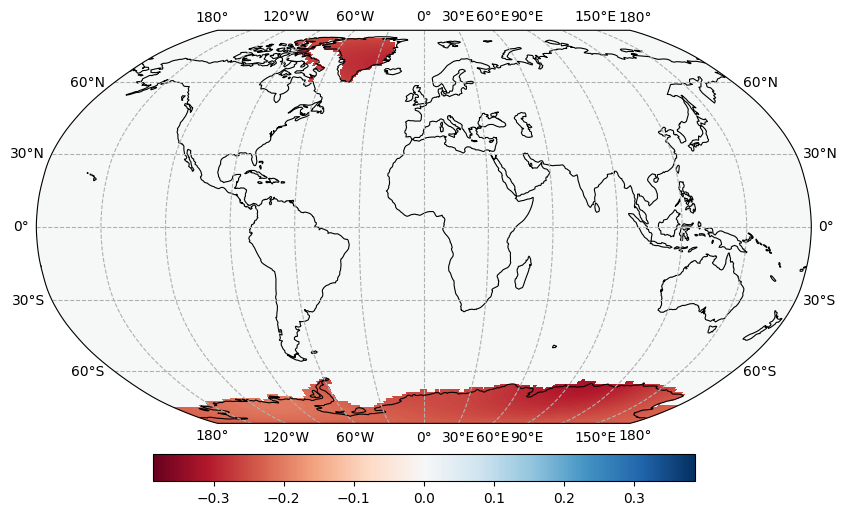

In [61]:
ice_change = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.2 * fp.mean_sea_floor_radius,
    pattern=IceSheetChange.UniformPattern(),
    ice_gmsl_std=0.001,
    gmsl_target_mean=0.01,
)
ice_thickness_measure = ice_change.ice_thickness

plot(ice_thickness_measure.sample(), symmetric=True)

We can confirm that this has the specified GMSL values. The operator that maps from ice thickness change to GMSL is provided by the IceSheetChange class.

In [62]:
true_gmsl = ice_thickness_measure.affine_mapping(
    operator=ice_change.ice_thickness_to_gmsl_operator
)

print(
    f"Expectation of true GMSL: {expectation(true_gmsl * 1000):.3f} mm"
)
print(
    f"Standard deviation of true GMSL: {standard_dev(true_gmsl * 1000):.3f} mm"
)

Expectation of true GMSL: 9.951 mm
Standard deviation of true GMSL: 0.998 mm


Under the hood, the IceSheetChange class also provides the SLC and SSHC fields:

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x152848cb0>)

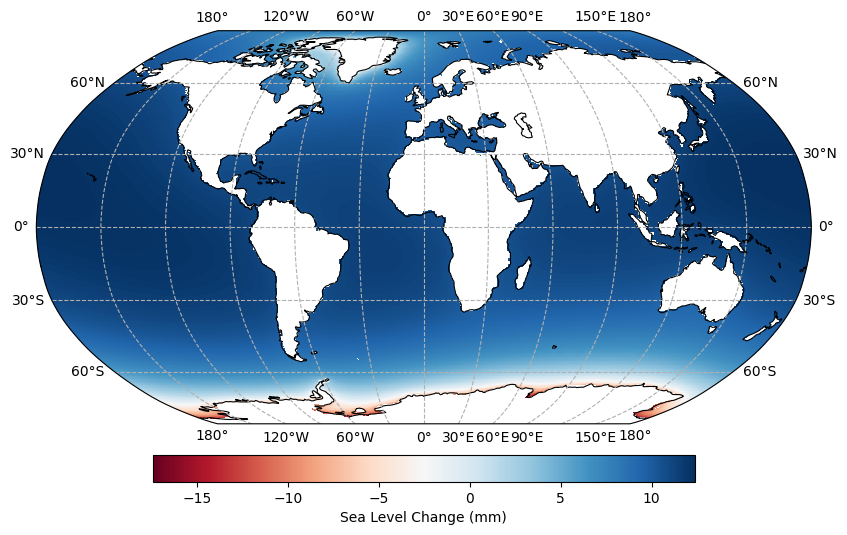

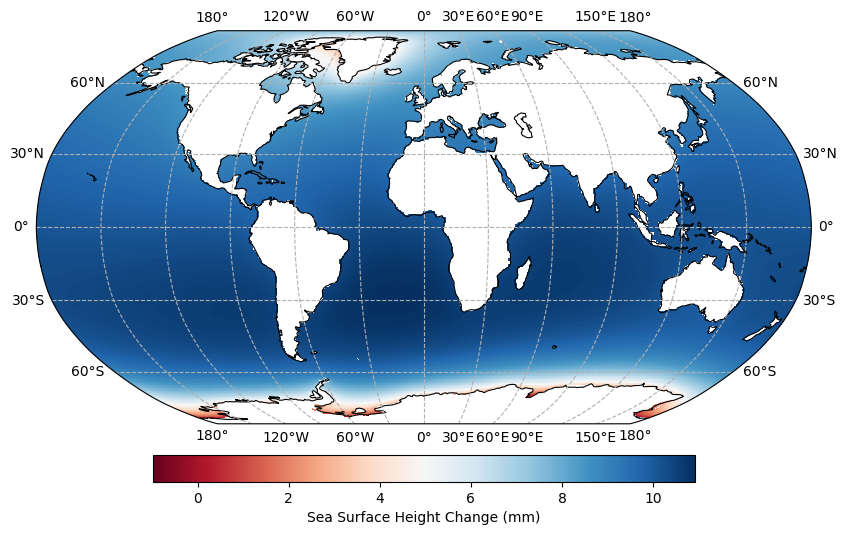

In [63]:
slc = ice_change.ice_slc
sshc = ice_change.ice_ssh

plot(
    slc.expectation * fp.ocean_projection() * 1000,
    colorbar_label="Sea Level Change (mm)",
)
plot(
    sshc.expectation * fp.ocean_projection() * 1000,
    colorbar_label="Sea Surface Height Change (mm)",
)

We can take samples from these distributions and plot their values:

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x152c508f0>)

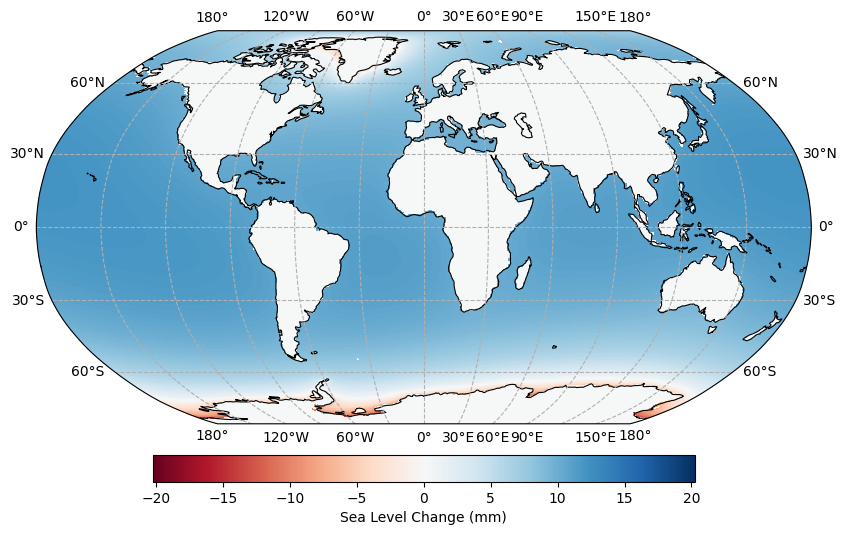

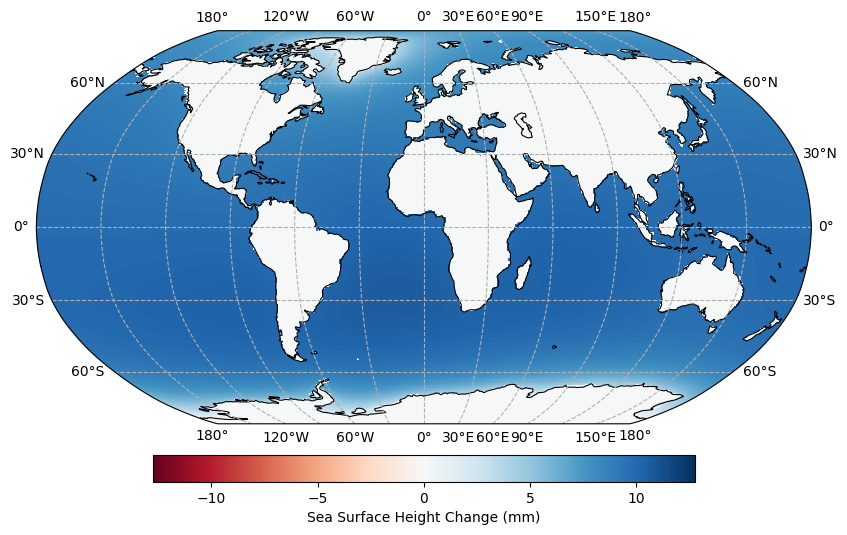

In [64]:
samples = ice_change.sample()  # draw linked samples from the ice thickness, and derive their SLC and SSH

plot(
    samples.ice_slc * 1000,
    symmetric=True,
    colorbar_label="Sea Level Change (mm)",
)
plot(
    samples.ice_ssh * 1000,
    symmetric=True,
    colorbar_label="Sea Surface Height Change (mm)",
)

We can then estimate the GMSL difference between the true value and estimation.

In [79]:
altimetry_operator = averaging_operator(
    sshc.domain,
    [
        fp.altimetry_projection(value=0)
        / fp.integrate(fp.altimetry_projection(value=0))
    ],
)

estimated_gmsl_from_sshc = sshc.affine_mapping(
    operator=altimetry_operator
)

print(type(estimated_gmsl_from_sshc))

print(
    f"Expectation of GMSL change from SSHC: {expectation(estimated_gmsl_from_sshc * 1000):.3f} mm"
)
print(
    f"Standard deviation of GMSL change from SSHC: {standard_dev(estimated_gmsl_from_sshc * 1000):.3f} mm"
)

# and as a reminder:

print(
    f"Expectation of true GMSL: {expectation(true_gmsl * 1000):.3f} mm"
)
print(
    f"Standard deviation of true GMSL: {standard_dev(true_gmsl * 1000):.3f} mm"
)

<class 'pygeoinf.gaussian_measure.GaussianMeasure'>
Expectation of GMSL change from SSHC: 9.831 mm
Standard deviation of GMSL change from SSHC: 0.988 mm
Expectation of true GMSL: 9.951 mm
Standard deviation of true GMSL: 0.998 mm


To compare the true and estimation GMSL measures, we can plot them:

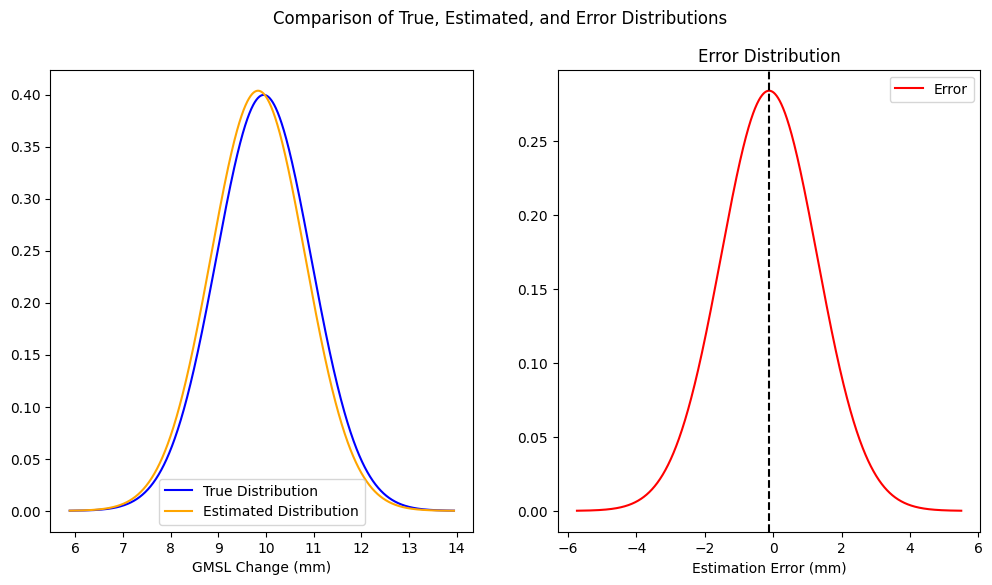

In [66]:
fig, (ax1, ax2) = error_plot(
    true_measure=true_gmsl * 1000,
    estimation_measure=estimated_gmsl_from_sshc * 1000,
    ax1_xlabel="GMSL Change (mm)",
    ax2_xlabel="Estimation Error (mm)",
)

## Regional differences

We can look and see what the regional error is as well, for example in the Caribbean or Northern Europe.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x1502cf8f0>)

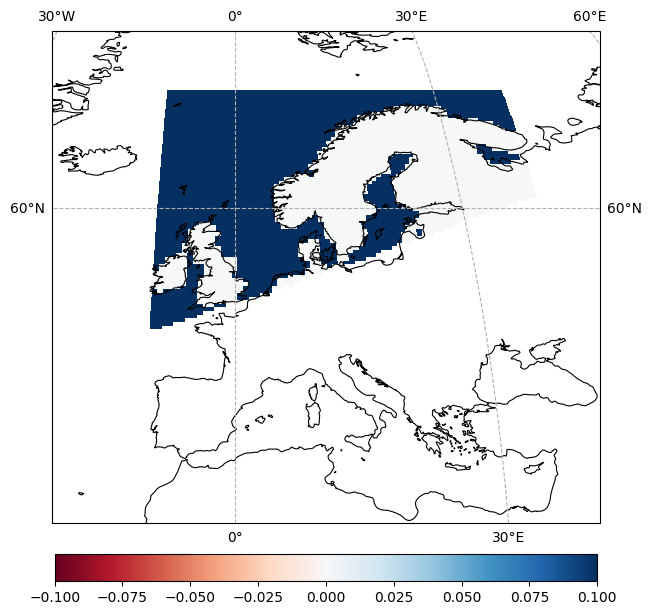

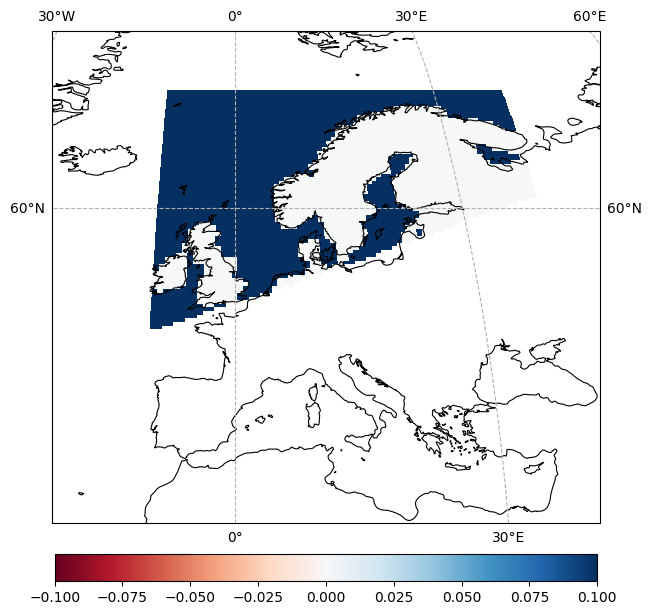

In [ ]:
region = "NEU"
# region = "CAR"

val = np.max(
    [
        np.abs(
            slc.expectation
            * fp.regionmask_projection(region)
            * fp.ocean_function
            * 1000
        ).max(),
        np.abs(
            sshc.expectation
            * fp.regionmask_projection(region)
            * fp.ocean_function
            * 1000
        ).max(),
    ]
)
plot(
    slc.expectation
    * 1000
    * fp.regionmask_projection(region)
    * fp.ocean_function,
    vmax=val,
    vmin=-val,
    # map_extent=(-100, -30, -10, 50), # Caribbean region
    map_extent=(-20, 40, 30, 80),  # NEU region
)
plot(
    sshc.expectation
    * 1000
    * fp.regionmask_projection(region)
    * fp.ocean_function,
    vmax=val,
    vmin=-val,
    # map_extent=(-100, -30, -10, 50), # Caribbean region
    map_extent=(-20, 40, 30, 80),  # NEU region
)

Visually, these don't seem too different. However we can explore how the GMSL change is represented by satellite data.

We can define an averaging operator for this region:

In [87]:
car_sshc_averaging_op = averaging_operator(
    sshc.domain,
    [
        (
            fp.regionmask_projection(region, value=0.0)
            * fp.ocean_projection(value=0)
        )
        / fp.integrate(
            (
                fp.regionmask_projection(region, value=0)
                * fp.ocean_projection(value=0)
            )
        )
    ],
)
car_slc_averaging_op = averaging_operator(
    slc.domain,
    [
        (
            fp.regionmask_projection(region, value=0.0)
            * fp.ocean_projection(value=0)
        )
        / fp.integrate(
            (
                fp.regionmask_projection(region, value=0)
                * fp.ocean_projection(value=0)
            )
        )
    ],
)

estimated_regional_gmsl = sshc.affine_mapping(
    operator=car_sshc_averaging_op
)
regional_gmsl = slc.affine_mapping(
    operator=car_slc_averaging_op
)

This can then be plotted:

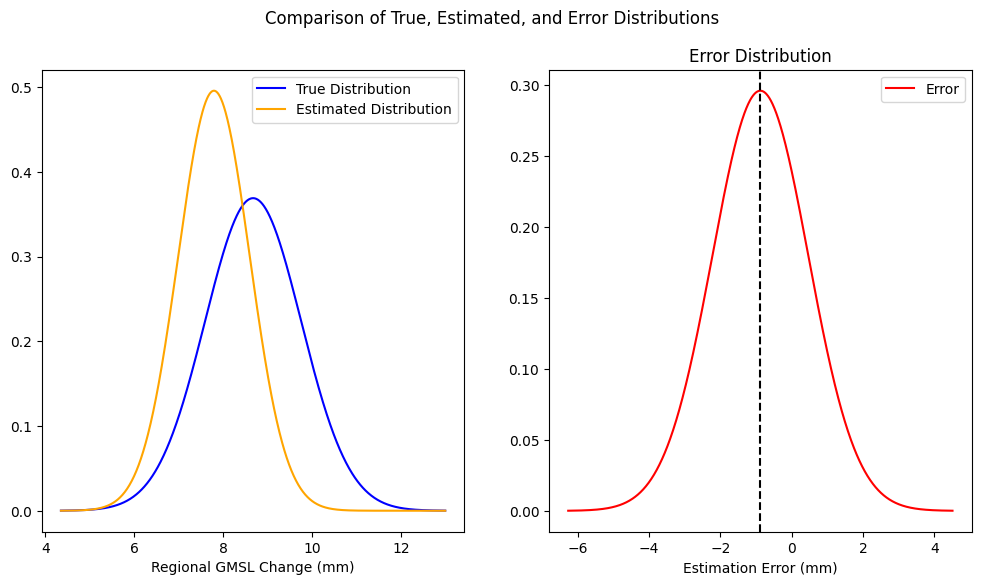

In [88]:
fig, (ax1, ax2) = error_plot(
    true_measure=regional_gmsl * 1000,
    estimation_measure=estimated_regional_gmsl * 1000,
    ax1_xlabel="Regional GMSL Change (mm)",
    ax2_xlabel="Estimation Error (mm)",
)

This shows that regionally the error is greater and, critically, different to the global error.

This sort of variation can be shown by calculating the error field, and then calculating the expectation and sampling the pointwise standard deviation. It is worth noting, however that this pointwise standard deviation looses the covariance relationship between locations.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x15735b5f0>)

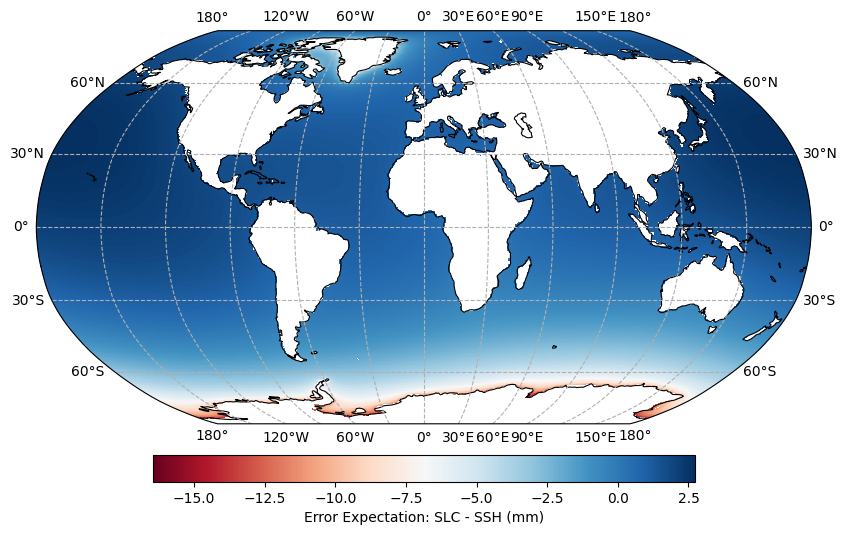

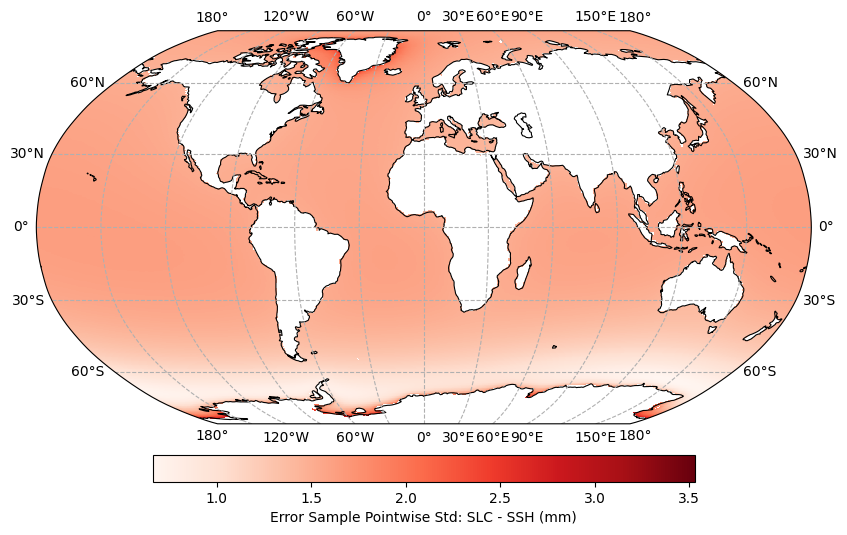

In [99]:
error = ice_change.ice_slc - ice_change.ice_ssh

plot(
    error.expectation * 1000 * fp.ocean_projection(),
    colorbar_label="Error Expectation: SLC - SSH (mm)",
)

plot(
    error.sample_pointwise_std(20)
    * 1000
    * fp.ocean_projection(),
    colorbar_label="Error Sample Pointwise Std: SLC - SSH (mm)",
    cmap="Reds",
)